In [212]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mutual_info_score
from IPython.display import display
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from scipy.special import expit

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score

Dataset

In [213]:
bm_csv = "https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv"
bm_df = pd.read_csv(bm_csv)

Data preparation \
Check if the missing values are presented in the features. \
If there are missing values: \
For categorical features, replace them with 'NA' \
For numerical features, replace with with 0.0

In [214]:
bm_df.dtypes

lead_source                  object
industry                     object
number_of_courses_viewed      int64
annual_income               float64
employment_status            object
location                     object
interaction_count             int64
lead_score                  float64
converted                     int64
dtype: object

In [215]:
bm_df.head(20)

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,NaN,1,79450.0,unemployed,south_america,4,0.94,1
1,social_media,retail,1,46992.0,employed,south_america,1,0.80,0
2,events,healthcare,5,78796.0,unemployed,australia,3,0.69,1
3,paid_ads,retail,2,83843.0,NaN,australia,1,0.87,0
4,referral,education,3,85012.0,self_employed,europe,3,0.62,1
5,events,manufacturing,1,59904.0,NaN,africa,6,0.83,1
6,social_media,technology,0,51283.0,NaN,middle_east,2,0.57,0
7,social_media,NaN,5,62975.0,student,europe,4,0.62,1
8,referral,healthcare,4,38648.0,unemployed,south_america,2,0.86,1
9,paid_ads,other,3,59866.0,student,australia,3,0.43,1


In [216]:
missing_columns = bm_df.columns[bm_df.isnull().any()]
print(f"Columns with missing values are:{missing_columns.values}")

Columns with missing values are:['lead_source' 'industry' 'annual_income' 'employment_status' 'location']


In [217]:
bm_df.columns

Index(['lead_source', 'industry', 'number_of_courses_viewed', 'annual_income',
       'employment_status', 'location', 'interaction_count', 'lead_score',
       'converted'],
      dtype='object')

In [218]:
# replace with NA
def fill_categorical(df, column):
    return df[column].fillna(value="NA")

In [219]:
# replace with 0.0
def fill_numerical(df, column):
    return df[column].fillna(value=0.0)

In [220]:
categorical_features = list(bm_df.select_dtypes(include=["object"]).columns)

for column_missing in missing_columns:
    if column_missing in categorical_features:
        bm_df[column_missing] = fill_categorical(bm_df, column_missing)
    else:
        bm_df[column_missing] = fill_numerical(bm_df, column_missing)

In [221]:
missing_columns = bm_df.columns[bm_df.isnull().any()]
print(f"Columns with missing values are:{missing_columns.values}")

Columns with missing values are:[]


In [222]:
bm_df.head(20)

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,NA,1,79450.0,unemployed,south_america,4,0.94,1
1,social_media,retail,1,46992.0,employed,south_america,1,0.80,0
2,events,healthcare,5,78796.0,unemployed,australia,3,0.69,1
3,paid_ads,retail,2,83843.0,NA,australia,1,0.87,0
4,referral,education,3,85012.0,self_employed,europe,3,0.62,1
5,events,manufacturing,1,59904.0,NA,africa,6,0.83,1
6,social_media,technology,0,51283.0,NA,middle_east,2,0.57,0
7,social_media,NA,5,62975.0,student,europe,4,0.62,1
8,referral,healthcare,4,38648.0,unemployed,south_america,2,0.86,1
9,paid_ads,other,3,59866.0,student,australia,3,0.43,1


Question 1\
What is the most frequent observation (mode) for the column industry?

In [223]:
mst_frqnt_obsrvtn = bm_df.industry.value_counts(ascending=False)
print(mst_frqnt_obsrvtn)

industry
retail           203
finance          200
other            198
healthcare       187
education        187
technology       179
manufacturing    174
NA               134
Name: count, dtype: int64


retail is the most common observation for the industry column

Question 2\
Create the correlation matrix for the numerical features of your dataset. In a correlation matrix, you compute the correlation coefficient between every pair of features.

What are the two features that have the biggest correlation?

In [224]:
numerical_features = list(bm_df.select_dtypes(include=["int64", "float64"]).columns)
numerical_features.remove("converted")
corr_nmrc_ftrs = bm_df[numerical_features].corr()
corr_nmrc_ftrs

,number_of_courses_viewed,annual_income,interaction_count,lead_score
number_of_courses_viewed,1.000000,0.009770,-0.023565,-0.004879
annual_income,0.009770,1.000000,0.027036,0.015610
interaction_count,-0.023565,0.027036,1.000000,0.009888
lead_score,-0.004879,0.015610,0.009888,1.000000


annual_income and interaction_count with a positive correlation of 0.027036?

In [225]:
#corr of numerical features using absolute value to consider negative correlations
corr_mtrx = bm_df[numerical_features].corr().abs()
#pivot column names and order in descending order 
corr_pairs = corr_mtrx.unstack().sort_values(ascending=False)
#filter matrix diagonal and remove duplicate feature pair entries
bggst_corr = corr_pairs[corr_pairs < 1.0].drop_duplicates()
print(f"{bggst_corr.index[0]} with an absolute correlation of {bggst_corr.values[0]} \n are the two features with biggest correlation")

('annual_income', 'interaction_count') with an absolute correlation of 0.02703647240481443 
 are the two features with biggest correlation


Split the data \
Split your data in train/val/test sets with 60%/20%/20% distribution. \
Use Scikit-Learn for that (the train_test_split function) and set the seed to 42. \
Make sure that the target value y is not in your dataframe.

In [226]:
len_df = len(bm_df)
len_vldtn = int(0.2 * len_df)
len_tst = int(0.2 * len_df)
len_trn = len_df - (len_vldtn + len_tst)
print(len_df)
print(len_trn)
print(len_vldtn)
print(len_tst)

1462
878
292
292


Is interesting to see how the splits are handled by the train_test_split function

In [227]:
train, test_vldtn = train_test_split(bm_df, test_size=0.4, random_state=42)
vldtn, test = train_test_split(test_vldtn, test_size=0.5, random_state=42)
print(len(train))
print(len(test_vldtn))
print(len(vldtn))
print(len(test))

877
585
292
293


In [228]:
train = train.reset_index(drop=True)
vldtn = train.reset_index(drop=True)
test = train.reset_index(drop=True)

y_vldtn = vldtn.converted.values
y_test = test.converted.values

del vldtn["converted"]
del test["converted"]

Question 3 \
Calculate the mutual information score between y and other categorical variables in the dataset. \
Use the training set only. \
Round the scores to 2 decimals using round(score, 2).

In [229]:
def calculate_mi(series):
    return round(mutual_info_score(series, train.converted), 2)

In [230]:
mi_score = train[categorical_features].apply(calculate_mi)
mi_score = mi_score.sort_values(ascending=False).to_frame(name="mutual_info_score")

In [231]:
display(mi_score)

,mutual_info_score
lead_source,0.03
industry,0.02
employment_status,0.02
location,0.00


lead_source has the biggest mutual info score

Question 4 \
Now let's train a logistic regression. \
Remember that we have several categorical variables in the dataset. Include them using one-hot encoding. \
Fit the model on the training dataset. \
To make sure the results are reproducible across different versions of Scikit-Learn, fit the model with these parameters: \
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42) \
Calculate the accuracy on the validation dataset and round it to 2 decimal digits.

In [232]:
# removing y from train dataframe
y_train = train.converted.values

del train["converted"]

In [233]:
#one-hot encoding
train_dct = train[categorical_features + numerical_features].to_dict(orient="records")

In [234]:
train_dct[0]

{'lead_source': 'referral',
 'industry': 'finance',
 'employment_status': 'unemployed',
 'location': 'south_america',
 'number_of_courses_viewed': 1,
 'annual_income': 61705.0,
 'interaction_count': 4,
 'lead_score': 0.65}

In [235]:
# return dense arrays
dct_vctrzr = DictVectorizer(sparse=False)

In [236]:
dct_vctrzr.fit(train_dct)

,dtype,<class 'numpy.float64'>
,separator,'='
,sparse,False
,sort,True


In [237]:
X_train = dct_vctrzr.transform(train_dct)

In [238]:
X_train.shape

(877, 31)

In [239]:
dct_vctrzr.get_feature_names_out()

array(['annual_income', 'employment_status=NA',
       'employment_status=employed', 'employment_status=self_employed',
       'employment_status=student', 'employment_status=unemployed',
       'industry=NA', 'industry=education', 'industry=finance',
       'industry=healthcare', 'industry=manufacturing', 'industry=other',
       'industry=retail', 'industry=technology', 'interaction_count',
       'lead_score', 'lead_source=NA', 'lead_source=events',
       'lead_source=organic_search', 'lead_source=paid_ads',
       'lead_source=referral', 'lead_source=social_media', 'location=NA',
       'location=africa', 'location=asia', 'location=australia',
       'location=europe', 'location=middle_east',
       'location=north_america', 'location=south_america',
       'number_of_courses_viewed'], dtype=object)

In [240]:
# train logistic regression
lg_rgrssn = LogisticRegression(solver="liblinear", C=1.0, max_iter=1000, random_state=42)
lg_rgrssn.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [241]:
vldtn_dct = vldtn[categorical_features + numerical_features].to_dict(orient="records")

In [242]:
X_vldtn = dct_vctrzr.transform(vldtn_dct)

In [243]:
lg_rgrssn.predict_proba(X_vldtn)

array([[0.40345679, 0.59654321],
       [0.33161245, 0.66838755],
       [0.28613865, 0.71386135],
       ...,
       [0.61628953, 0.38371047],
       [0.42075643, 0.57924357],
       [0.42311263, 0.57688737]], shape=(877, 2))

In [244]:
y_prdct_vldtn = lg_rgrssn.predict_proba(X_vldtn)[:, 1]

In [245]:
converted = y_prdct_vldtn > 0.5

In [246]:
acc = round((y_vldtn == converted).mean(), 2)

In [247]:
print(f"The accuracy of the model on the validation dataset scored: {acc}")

The accuracy of the model on the validation dataset scored: 0.75


In [248]:
prdctns = pd.DataFrame()
prdctns["probability"] = y_prdct_vldtn
prdctns["prediction"] = converted.astype(int)
prdctns["actual"] = y_vldtn

In [249]:
prdctns["correct"] = prdctns.prediction == prdctns.actual

In [250]:
prdctns.correct.mean()

np.float64(0.7468643101482326)

Model Interpretation

Below you can see how many features were used to train the previous model by combining categorical and numerical, recall one-hot encoding was applied to categorical features using DictVectorizer

In [251]:
dict(zip(dct_vctrzr.get_feature_names_out(), lg_rgrssn.coef_[0].round(3)))

{'annual_income': np.float64(-0.0),
 'employment_status=NA': np.float64(-0.014),
 'employment_status=employed': np.float64(0.03),
 'employment_status=self_employed': np.float64(0.018),
 'employment_status=student': np.float64(0.012),
 'employment_status=unemployed': np.float64(-0.106),
 'industry=NA': np.float64(-0.021),
 'industry=education': np.float64(0.054),
 'industry=finance': np.float64(-0.025),
 'industry=healthcare': np.float64(-0.022),
 'industry=manufacturing': np.float64(-0.011),
 'industry=other': np.float64(-0.004),
 'industry=retail': np.float64(-0.016),
 'industry=technology': np.float64(-0.014),
 'interaction_count': np.float64(0.299),
 'lead_score': np.float64(0.047),
 'lead_source=NA': np.float64(0.009),
 'lead_source=events': np.float64(-0.014),
 'lead_source=organic_search': np.float64(-0.014),
 'lead_source=paid_ads': np.float64(-0.096),
 'lead_source=referral': np.float64(0.071),
 'lead_source=social_media': np.float64(-0.015),
 'location=NA': np.float64(0.005),


I used numerical features, to see what is going on here

In [252]:
train_nmrc_dct = train[numerical_features].to_dict(orient="records")
vldtn_nmrc_dct = vldtn[numerical_features].to_dict(orient="records")

In [253]:
dct_vctrzr_nmrc = DictVectorizer(sparse=False)

In [254]:
dct_vctrzr_nmrc.fit(train_nmrc_dct)

,dtype,<class 'numpy.float64'>
,separator,'='
,sparse,False
,sort,True


In [255]:
X_train_nmrc = dct_vctrzr_nmrc.transform(train_nmrc_dct)

In [256]:
dct_vctrzr_nmrc.get_feature_names_out()

array(['annual_income', 'interaction_count', 'lead_score',
       'number_of_courses_viewed'], dtype=object)

In [257]:
# train logistic regression
lg_rgrssn_nmrc = LogisticRegression(solver="liblinear", C=1.0, max_iter=1000, random_state=42)
lg_rgrssn_nmrc.fit(X_train_nmrc, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [258]:
#bias term
w_0 = lg_rgrssn_nmrc.intercept_[0]
round(w_0, 3)

np.float64(-0.101)

In [259]:
# weights or coefficients
wghts = dict(zip(dct_vctrzr_nmrc.get_feature_names_out(), lg_rgrssn_nmrc.coef_[0]))
wghts

{'annual_income': np.float64(-1.7640694647317834e-05),
 'interaction_count': np.float64(0.25612747760590476),
 'lead_score': np.float64(0.049363581586353025),
 'number_of_courses_viewed': np.float64(0.4857957500914265)}

In [260]:
#feature values, did it this way so it is easier to follow, look at the index
ftr = vldtn[numerical_features].head(1)
ftr

,number_of_courses_viewed,annual_income,interaction_count,lead_score
0,1,61705.0,4,0.65


In [261]:
def get_sigmoid_of(sum_of_weights):
    return expit(sum_of_weights)

In [262]:
#using bias term, weights or coefficients and sigmoid step by step
#match feature value with corresponding weight or coefficient
print("w0:",get_sigmoid_of(w_0))

print("w0 + x1*w1:",get_sigmoid_of(
    w_0 + 
    ftr.number_of_courses_viewed.iloc[0]*wghts.get("number_of_courses_viewed")
))

print("w0 + x1*w1 + x2*w2:",get_sigmoid_of(
    w_0 + 
    ftr.number_of_courses_viewed.iloc[0]*wghts.get("number_of_courses_viewed") +
    ftr.annual_income.iloc[0]*wghts.get("annual_income")
))

print("w0 + x1*w1 + x2*w2 + x3*w3:",get_sigmoid_of(
    w_0 + 
    ftr.number_of_courses_viewed.iloc[0]*wghts.get("number_of_courses_viewed") +
    ftr.annual_income.iloc[0]*wghts.get("annual_income") + 
    ftr.interaction_count.iloc[0]*wghts.get("interaction_count")
))

print("w0 + x1*w1 + x2*w2 + x3*w3 + x4*w4:",get_sigmoid_of(
    w_0 + 
    ftr.number_of_courses_viewed.iloc[0]*wghts.get("number_of_courses_viewed") +
    ftr.annual_income.iloc[0]*wghts.get("annual_income") + 
    ftr.interaction_count.iloc[0]*wghts.get("interaction_count") + 
    ftr.lead_score.iloc[0]*wghts.get("lead_score")
))

w0: 0.47478632538252735
w0 + x1*w1: 0.5950436384039293
w0 + x1*w1 + x2*w2: 0.33100045485675234
w0 + x1*w1 + x2*w2 + x3*w3: 0.5795304831562733
w0 + x1*w1 + x2*w2 + x3*w3 + x4*w4: 0.5873285475624324


In [263]:
#rounding result to 5 decimals just to show a bit of precision
manually_sigmoid = np.round(0.5873285475624324, 5)
manually_sigmoid

np.float64(0.58733)

Now is time to get the probability from the trained model and compare

In [264]:
X_vldtn_nmrc = dct_vctrzr_nmrc.transform(vldtn_nmrc_dct)

In [265]:
vldtn_prdctns = lg_rgrssn_nmrc.predict_proba(X_vldtn_nmrc)[:, 1].round(5)
lg_rgrssn_prdctn = vldtn_prdctns[0]
lg_rgrssn_prdctn

np.float64(0.58733)

In [266]:
print(f"Model Interpretation and prediction of 1st observation in validation split is the same? {'Yes' if manually_sigmoid==lg_rgrssn_prdctn else 'No'}")

Model Interpretation and prediction of 1st observation in validation split is the same? Yes


Question 5 \
Let's find the least useful feature using the feature elimination technique. \
Train a model using the same features and parameters as in Q4 (without rounding). \
Now exclude each feature from this set and train a model without it. Record the accuracy for each model. \
For each feature, calculate the difference between the original accuracy and the accuracy without the feature.

In [267]:
def get_acc_ftr_rmvl(train_df, vldtn_df, y_train, y_vldtn, ftrs_to_excld):
    acc_scores = {}
    #use None to identify base model and not remove features
    ftrs_to_excld.insert(0, None)
    #instantiate DictVectorizer
    dct_vctrzr = DictVectorizer(sparse=False)
    for ftr in ftrs_to_excld:
        if ftr:
            #remove feature from train_df and review
            del train_df[ftr]
            print(f"Removed: {ftr} from train_df")
            print(train_df.columns.values)
            #remove feature from vldtn_df and review
            del vldtn_df[ftr]
            print(f"Removed: {ftr} from vldtn_df")
            print(vldtn_df.columns.values)
        #get dict of features
        train_dct = train_df.to_dict(orient="records")
        vldtn_dct = vldtn_df.to_dict(orient="records")
        #map feature names
        dct_vctrzr.fit(train_dct)
        #get numerical feature matrix
        X_train = dct_vctrzr.transform(train_dct)
        X_vldtn = dct_vctrzr.transform(vldtn_dct)
        #train logistic regression
        lg_rg = LogisticRegression(solver="liblinear", C=1.0, max_iter=1000, random_state=42)
        lg_rg.fit(X_train, y_train)
        #predict using model
        prdctn = lg_rg.predict_proba(X_vldtn)[:, 1]
        #get accuracy and save to acc_scores, key is excluded feature name
        converted = prdctn > 0.5
        acc = (y_vldtn == converted).mean()
        if ftr:
            acc_scores[ftr] = acc
        else:
            acc_scores["base"] = acc
    return acc_scores

In [268]:
# get accuracy from base model and model with each excluded feature
train_cp = train.copy()
vldtn_cp = vldtn.copy()
features = ["industry", "employment_status", "lead_score"]
acc_scores = get_acc_ftr_rmvl(train_cp, vldtn_cp, y_train, y_vldtn, features)
acc_scores

Removed: industry from train_df
['lead_source' 'number_of_courses_viewed' 'annual_income'
 'employment_status' 'location' 'interaction_count' 'lead_score']
Removed: industry from vldtn_df
['lead_source' 'number_of_courses_viewed' 'annual_income'
 'employment_status' 'location' 'interaction_count' 'lead_score']
Removed: employment_status from train_df
['lead_source' 'number_of_courses_viewed' 'annual_income' 'location'
 'interaction_count' 'lead_score']
Removed: employment_status from vldtn_df
['lead_source' 'number_of_courses_viewed' 'annual_income' 'location'
 'interaction_count' 'lead_score']
Removed: lead_score from train_df
['lead_source' 'number_of_courses_viewed' 'annual_income' 'location'
 'interaction_count']
Removed: lead_score from vldtn_df
['lead_source' 'number_of_courses_viewed' 'annual_income' 'location'
 'interaction_count']


{'base': np.float64(0.7468643101482326),
 'industry': np.float64(0.750285062713797),
 'employment_status': np.float64(0.7445838084378563),
 'lead_score': np.float64(0.7445838084378563)}

In [269]:
#get base score and remove from acc_scores
base_score = acc_scores.get("base")
del acc_scores["base"]

In [270]:
#get smallest difference of acc_scores between base model and each model
smallest_diff = min(acc_scores, key=lambda score: base_score - acc_scores[score])
print(f"Feature with smallest difference is: {smallest_diff}")

Feature with smallest difference is: industry


Just double checking

In [271]:
print(f"Difference of base, base without industry: \t\t{0.7468643101482326 - 0.750285062713797}")
print(f"Difference of base, base without employment_status: \t{0.7468643101482326 - 0.7445838084378563}")
print(f"Difference of base, base without lead_score: \t\t{0.7468643101482326 - 0.7445838084378563}")

Difference of base, base without industry: 		-0.0034207525655644
Difference of base, base without employment_status: 	0.0022805017103763037
Difference of base, base without lead_score: 		0.0022805017103763037


Question 6 \
Now let's train a regularized logistic regression. \
Let's try the following values of the parameter C: [0.01, 0.1, 1, 10, 100]. \
Train models using all the features as in Q4. \
Calculate the accuracy on the validation dataset and round it to 3 decimal digits.

In [272]:
train.head()

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score
0,referral,finance,1,61705.0,unemployed,south_america,4,0.65
1,referral,education,1,55199.0,employed,south_america,4,0.09
2,referral,retail,1,40841.0,self_employed,africa,4,0.61
3,referral,other,1,28242.0,employed,middle_east,3,0.84
4,events,retail,0,64775.0,self_employed,south_america,3,0.70


In [273]:
nmrc_ftrs = train[numerical_features]

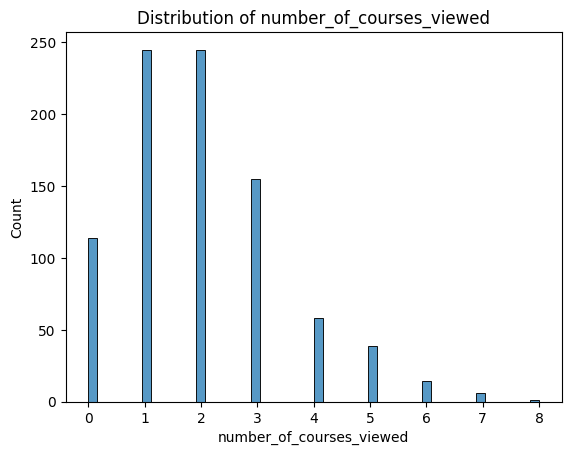

In [274]:
sns.histplot(nmrc_ftrs.number_of_courses_viewed, bins=50)
plt.title("Distribution of number_of_courses_viewed")
plt.show()

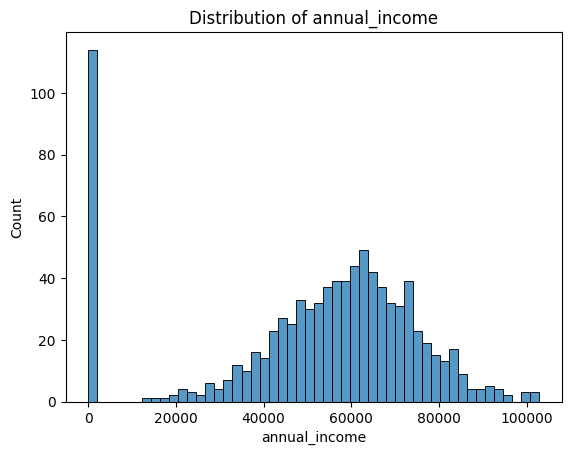

In [275]:
sns.histplot(nmrc_ftrs.annual_income, bins=50)
plt.title("Distribution of annual_income")
plt.show()

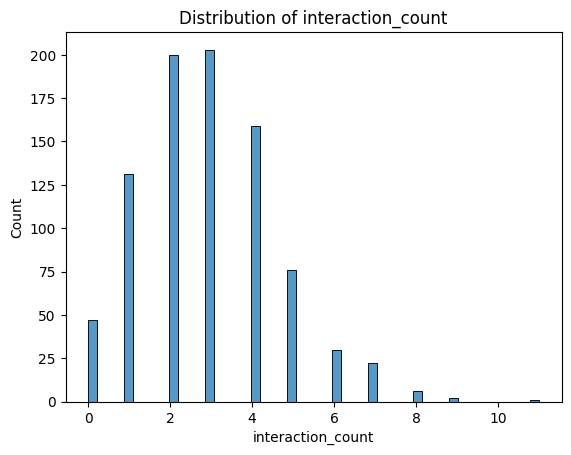

In [276]:
sns.histplot(nmrc_ftrs.interaction_count, bins=50)
plt.title("Distribution of interaction_count")
plt.show()

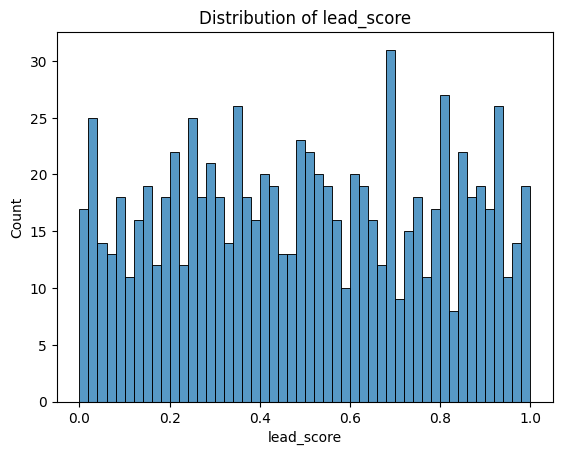

In [277]:
sns.histplot(nmrc_ftrs.lead_score, bins=50)
plt.title("Distribution of lead_score")
plt.show()

Once feature distributions are checked it can be seen that it would be helpful to standardize individual numeric features as the question is asking to apply regularization with C values different from 1.0

In [278]:
def get_acc_log_reg_rglrzd(train_df, vldtn_df, y_train, y_vldtn):
    acc_scores = {}
    #scale numeric features
    scaler = StandardScaler()
    X_train_nmrc = train_df[numerical_features].values
    X_train_nmrc = scaler.fit_transform(X_train_nmrc)
    #encode categorical features
    ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
    X_train_ctgrcl = ohe.fit_transform(train_df[categorical_features].values)
    #combine both preprocessed features fo training
    X_train = np.column_stack([X_train_nmrc, X_train_ctgrcl])
    #preprocess validation features
    X_vldtn_nmrc = vldtn_df[numerical_features].values
    X_vldtn_nmrc = scaler.transform(X_vldtn_nmrc)
    X_vldtn_ctgrcl = ohe.transform(vldtn_df[categorical_features].values)
    X_vldtn = np.column_stack([X_vldtn_nmrc, X_vldtn_ctgrcl])
    for rglrztn_c in [0.01, 0.1, 1, 10, 100]:
        #train logistic regression regularized with different C
        #lg_rg_rglrzd = LogisticRegression(solver="lbfgs", C=rglrztn_c, max_iter=1000, random_state=42)
        lg_rg_rglrzd = LogisticRegression(solver="liblinear", C=rglrztn_c, max_iter=1000, random_state=42)
        lg_rg_rglrzd.fit(X_train, y_train)
        #predict using model
        y_prdctn = lg_rg_rglrzd.predict_proba(X_vldtn)[:, 1]
        #get accuracy and save to acc_scores
        acc = accuracy_score(y_vldtn, y_prdctn >= 0.5)
        acc_scores[str(rglrztn_c)] = np.round(acc, 3)
    return acc_scores

In [279]:
train_cp = train.copy()
vldtn_cp = vldtn.copy()
acc_scores = get_acc_log_reg_rglrzd(train_cp, vldtn_cp, y_train, y_vldtn)
acc_scores

{'0.01': np.float64(0.846),
 '0.1': np.float64(0.871),
 '1': np.float64(0.879),
 '10': np.float64(0.879),
 '100': np.float64(0.879)}

In [280]:
best_acc = max(acc_scores, key=acc_scores.get)
print(f"Best accuracy is given by C: {best_acc}")

Best accuracy is given by C: 1
